In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

n = len(x)

sumX = np.sum(x)
sumY = np.sum(y)
sumXY = np.sum(x * y)
sumXSquare = np.sum(x ** 2)

slope = (n * sumXY - sumX * sumY) / (n * sumXSquare - sumX ** 2)
intercept = (sumY - slope * sumX) / n

print("Slope:", slope)
print("Intercept:", intercept)
print("Equation: y =", slope, "x +", intercept)

Slope: 0.6
Intercept: 2.2
Equation: y = 0.6 x + 2.2


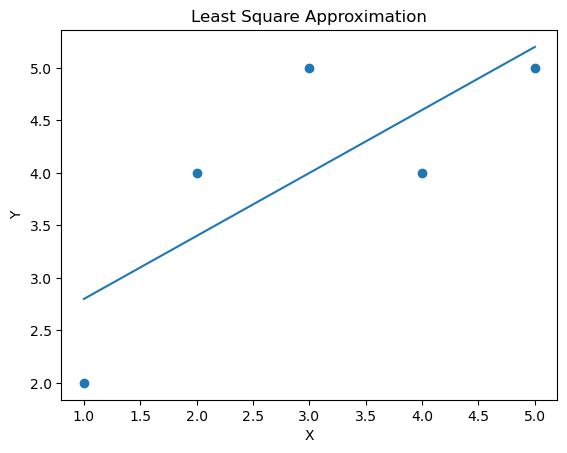

In [3]:
predictedY = slope * x + intercept

plt.scatter(x, y)
plt.plot(x, predictedY)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Square Approximation")
plt.show()

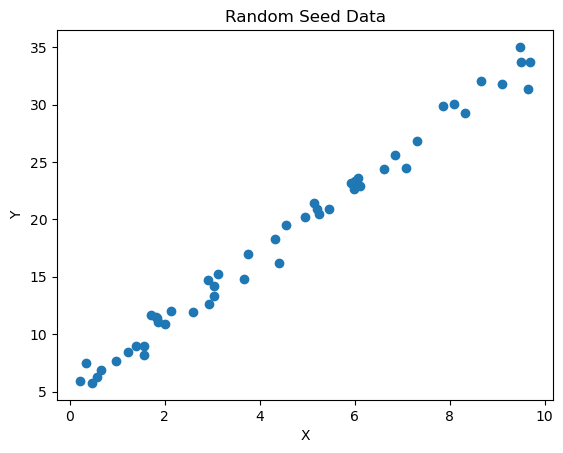

In [4]:
np.random.seed(42)

x = np.random.rand(50) * 10
y = 3 * x + 5 + np.random.randn(50)

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Random Seed Data")
plt.show()

In [5]:
slope = 0
intercept = 0

learningRate = 0.01
iterations = 1000
n = len(x)

for i in range(iterations):
    predictedY = slope * x + intercept

    slopeGradient = (-2 / n) * np.sum(x * (y - predictedY))
    interceptGradient = (-2 / n) * np.sum(y - predictedY)

    slope = slope - learningRate * slopeGradient
    intercept = intercept - learningRate * interceptGradient

print("Slope:", slope)
print("Intercept:", intercept)
print("Equation: y =", slope, "x +", intercept)

Slope: 2.9800754809604646
Intercept: 5.0816207242642335
Equation: y = 2.9800754809604646 x + 5.0816207242642335


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import os

os.chdir(r"D:\LabAssignments\ml\lab3")

print(os.getcwd())

D:\LabAssignments\ml\lab3


In [9]:
data = pd.read_csv("D:\LabAssignments\ml\lab3\Titanic-Dataset.csv")

print(data.head())
print(data.shape)
print(data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [10]:
data = data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]

print(data.head())

   Pclass     Sex   Age  SibSp  Parch     Fare
0       3    male  22.0      1      0   7.2500
1       1  female  38.0      1      0  71.2833
2       3  female  26.0      0      0   7.9250
3       1  female  35.0      1      0  53.1000
4       3    male  35.0      0      0   8.0500


In [11]:
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})

data = data.dropna()

print(data.isnull().sum())
print(data.head())

Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500


In [12]:
x = data[["Pclass", "Sex", "Age", "SibSp", "Parch"]].values
y = data["Fare"].values

In [13]:
xMean = np.mean(x, axis=0)
xStd = np.std(x, axis=0)

x = (x - xMean) / xStd

In [14]:
np.random.seed(42)

indices = np.random.permutation(len(x))

trainSize = int(0.8 * len(x))

trainIndices = indices[:trainSize]
testIndices = indices[trainSize:]

xTrain = x[trainIndices]
xTest = x[testIndices]

yTrain = y[trainIndices]
yTest = y[testIndices]

print("Training samples:", len(xTrain))
print("Testing samples:", len(xTest))

Training samples: 712
Testing samples: 179


In [15]:
xTrain = np.c_[np.ones(xTrain.shape[0]), xTrain]
xTest = np.c_[np.ones(xTest.shape[0]), xTest]

In [16]:
theta = np.linalg.inv(xTrain.T @ xTrain) @ xTrain.T @ yTrain

print("Coefficients:")
print(theta)

Coefficients:
[ 32.86645974 -29.55065265   2.32763704  -1.73051265   6.05184671
   7.61377357]


In [17]:
predictedY = xTest @ theta

print("Actual values:")
print(yTest[:10])

print("\nPredicted values:")
print(predictedY[:10])

Actual values:
[ 10.5      7.125   76.7292  65.      39.6     31.275   55.9     15.85
  10.5    110.8833]

Predicted values:
[36.03308255 -1.32627151 73.96289433 62.37276174 78.83526403 44.46064761
 80.03217066 21.08323688 35.63411367 83.28090839]


In [18]:
mse = np.mean((yTest - predictedY) ** 2)

print("Mean Squared Error:", mse)

Mean Squared Error: 689.003310900411


In [19]:
ssTotal = np.sum((yTest - np.mean(yTest)) ** 2)
ssResidual = np.sum((yTest - predictedY) ** 2)

r2 = 1 - (ssResidual / ssTotal)

print("R² Score:", r2)

R² Score: 0.5002551240123883


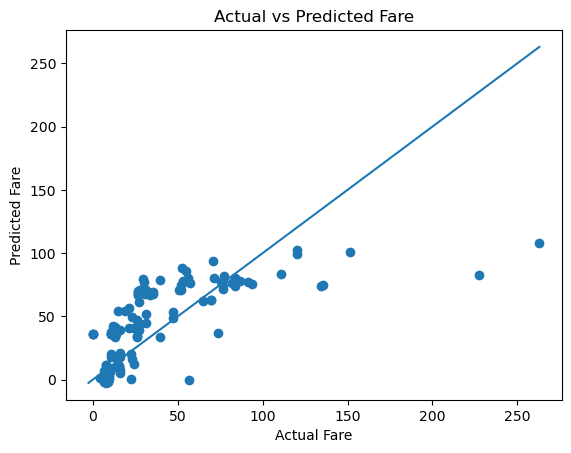

In [20]:
plt.scatter(yTest, predictedY)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

minimum = min(yTest.min(), predictedY.min())
maximum = max(yTest.max(), predictedY.max())

plt.plot([minimum, maximum], [minimum, maximum])

plt.show()